In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from torch.optim import AdamW
from tqdm import tqdm
from torchvision.utils import save_image

In [ ]:
!pip install transformers accelerate bitsandbytes peft torch torchvision

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Quantification en NF4 (4 bits)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

In [ ]:
model_path = "Zhengyi/LLaMA-Mesh"
model = AutoModelForCausalLM.from_pretrained(model_path, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(model_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

`low_cpu_mem_usage` was None, now default to True since model is quantized.


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.3k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

In [ ]:
for name, param in model.named_parameters():
    print(name)

for name, param in model.named_parameters():
    if "decoder" in name or "mesh" in name:
        print(name)

for name, param in model.named_parameters():
    if "decoder" in name:  # Adapter avec les noms trouvés avant
        print(f"{name} - Taille : {param.shape}")


model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.o_proj.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.post_attention_layernorm.weight
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.o_proj.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.post_attention_layernorm.weight
model.layers.2.self_attn.q_proj.weight
model.layers.2.self_attn.k_proj.weight
model.layers.2.self_attn.v_proj.weight
model.layers.2.self_attn.o_proj.weight
model.layers.2.mlp.gate_proj.weight
model.layers.2.mlp.up_proj.weight
model.layers.2.mlp.down_proj.weight
model.layers.2.inp

In [ ]:
# Définition de LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,  # Rank des matrices de Low-Rank Adaptation
    lora_alpha=32,  # Facteur de mise à l'échelle
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj"  # MLP
    ]
)

# lora_config = LoraConfig(
#     task_type=TaskType.CAUSAL_LM,
#     r=16,  # Rank des matrices de Low-Rank Adaptation
#     lora_alpha=32,  # Facteur de mise à l'échelle
#     lora_dropout=0.05,
#     target_modules=[
#         "all-linear"
#     ]
# )

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# all-linear not found in the model : car couches linéaires sont quantizées (appelées Linear4bit)

ValueError: Target modules {'all-linear'} not found in the base model. Please check the target modules and try again.

In [ ]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((409

In [ ]:
linear4bit_layers = []
for name, module in model.named_modules():
    if "Linear4bit" in str(type(module)):
        linear4bit_layers.append(name)

print("Linear4bit Layers Identified:")
for layer in linear4bit_layers:
    print(layer)

Linear4bit Layers Identified:
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp.gate_proj
model.layers.2.mlp.up_proj
model.layers.2.mlp.down_proj
model.layers.3.self_attn.q_proj
model.layers.3.self_attn.k_proj
model.layers.3.self_attn.v_proj
model.layers.3.self_attn.o_proj
model.layers.3.mlp.gate_proj
model.layers.3.mlp.up_proj
model.layers.3.mlp.down_proj
model.layers.4.self_attn.q_proj
model.layers.4.self_attn.k_proj
model.layers.4.self_attn.v_proj
model.layers.4.self_at

In [ ]:
# Chargement du dataset d'images et prétraitement
class MeshDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.img_list = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_list[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# Configuration du DataLoader
dataset_path = "path_to_images/"
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
train_dataset = MeshDataset(dataset_path, transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [ ]:
# Entraînement du modèle
optimizer = AdamW(model.parameters(), lr=1e-4)
model.train()
num_epochs = 3
for epoch in range(num_epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in loop:
        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())
print("Fine-tuning terminé !")

In [ ]:
# Test du modèle avec une image
test_img_path = "test_image.jpg"
test_img = Image.open(test_img_path).convert("RGB")
test_tensor = transform(test_img).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    generated_mesh = model(test_tensor)
save_image(generated_mesh, "generated_mesh.jpg")
print("Mesh généré et sauvegardé !")

## OBJ to PNG

In [ ]:
!git clone https://huggingface.co/datasets/dylanebert/objaverse-lowpoly-obj

In [ ]:
!pip install trimesh pyrender

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.1/962.1 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.1 MB/s eta 0:00:00
  Created wheel for PyOpenGL: filename=PyOpenGL-3.1.0-py3-none-any.whl size=1745193 sha256=401081d499894c25dd9cbd4e62fddd5cac68c4d227c246633f62785d9426f040
  Stored in directory: /root/.cache/pip/wheels/2f/37/f5/f88cd3dddf75bc3ce608e44bf8a79078c408bf1f351a50818e
Successfully built PyOpenGL
  Attempting uninstall: PyOpenGL
    Found existing installation: PyOpenGL 3.1.9
    Uninstalling PyOpenGL-3.1.9:
      Successfully uninstalled PyOpenGL-3.1.9


In [ ]:
import os
import numpy as np
import trimesh
import pyrender
import matplotlib.pyplot as plt
from PIL import Image
from pyrender import RenderFlags
from tqdm import tqdm

In [ ]:
# Total of 58582 .obj files in the dataset

input_root = "objaverse-lowpoly-obj"
output_root = "objaverse_converted"
os.makedirs(output_root, exist_ok=True)

def render_obj(obj_path, output_path, width=640, height=480):

    mesh = trimesh.load(obj_path)

    mesh_pyrender = pyrender.Mesh.from_trimesh(mesh, smooth=False)

    # Create a scene with a slightly gray background and ambient light
    scene = pyrender.Scene(bg_color=[0.95, 0.95, 0.95], ambient_light=[0.2, 0.2, 0.2])
    scene.add(mesh_pyrender)

    # Compute the bounding box center and dimensions
    bbox = mesh.bounds  # [[x_min, y_min, z_min], [x_max, y_max, z_max]]
    center = (bbox[0] + bbox[1]) / 2
    size = bbox[1] - bbox[0]
    max_dim = np.max(size)
    camera_distance = max_dim * 2

    # Compute the "density center" of the mesh
    dens_center = np.mean(mesh.vertices, axis=0)
    delta_y = np.arctan2(dens_center[0] - center[0], dens_center[2] - center[2])

    # Angles for tilting
    tilt_x = np.radians(-15)
    base_tilt_y = np.radians(-30)
    tilt_y = base_tilt_y + delta_y  # adjust based on density

    # Rotation matrices
    rot_x = np.array([
        [1, 0, 0, 0],
        [0, np.cos(tilt_x), -np.sin(tilt_x), 0],
        [0, np.sin(tilt_x),  np.cos(tilt_x), 0],
        [0, 0, 0, 1]
    ])

    rot_y = np.array([
        [ np.cos(tilt_y), 0, np.sin(tilt_y), 0],
        [0, 1, 0, 0],
        [-np.sin(tilt_y), 0, np.cos(tilt_y), 0],
        [0, 0, 0, 1]
    ])

    # Combined rotation
    R = rot_y @ rot_x

    # Translation
    T_offset = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, camera_distance],
        [0, 0, 0, 1]
    ])

    # Translation to shift coordinate system to object's center
    T_center = np.array([
        [1, 0, 0, center[0]],
        [0, 1, 0, center[1]],
        [0, 0, 1, center[2]],
        [0, 0, 0, 1]
    ])

    cam_pose = T_center @ R @ T_offset
    camera = pyrender.PerspectiveCamera(yfov=np.pi / 4.0, aspectRatio=width/height)
    scene.add(camera, pose=cam_pose)

    # Lighting
    key_light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=5.0)
    scene.add(key_light, pose=np.array([
        [ 1.0, 0.0,  0.0, center[0] - 0.5],
        [ 0.0, 0.0, -1.0, center[1] + 1.0],
        [ 0.0, 1.0,  0.0, center[2] + 1.0],
        [ 0.0, 0.0,  0.0, 1.0]
    ]))

    fill_light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=2.5)
    scene.add(fill_light, pose=np.array([
        [-1.0, 0.0,  0.0, center[0] + 0.5],
        [ 0.0, 0.0, -1.0, center[1]],
        [ 0.0, 1.0,  0.0, center[2] + 0.5],
        [ 0.0, 0.0,  0.0, 1.0]
    ]))

    back_light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=2.0)
    scene.add(back_light, pose=np.array([
        [ 0.0, 0.0,  1.0, center[0]],
        [ 0.0, 1.0,  0.0, center[1] + 1.0],
        [-1.0, 0.0,  0.0, center[2] - 0.5],
        [ 0.0, 0.0,  0.0, 1.0]
    ]))

    cam_light = pyrender.DirectionalLight(color=np.ones(3), intensity=3.0)
    scene.add(cam_light, pose=cam_pose)


    renderer = pyrender.OffscreenRenderer(width, height)
    color, depth = renderer.render(scene, flags=RenderFlags.SHADOWS_DIRECTIONAL)

    plt.imsave(output_path, color)
    #print(f"Saved: {output_path}")

if __name__ == "__main__":

    selected_subfolders = ['000-003', '000-004', '000-005']

    obj_files = []
    for root, dirs, files in os.walk(input_root):
        rel_folder = os.path.basename(root)
        if rel_folder not in selected_subfolders:
            continue
        for file_name in files:
            if file_name.endswith(".obj"):
                obj_files.append(os.path.join(root, file_name))

    print(f"Found {len(obj_files)} OBJ files")

    counter = 0
    total_files = len(obj_files)

    for obj_path in obj_files:

        rel_path = os.path.relpath(os.path.dirname(obj_path), input_root)
        out_dir = os.path.join(output_root, rel_path)
        os.makedirs(out_dir, exist_ok=True)

        # Output path
        file_name = os.path.basename(obj_path)
        output_path = os.path.join(out_dir, file_name.replace(".obj", ".png"))

        render_obj(obj_path, output_path)

        counter += 1
        if counter % 50 == 0:
            progress_percentage = (counter / total_files) * 100
            print(f"{counter} objets convertis... ({progress_percentage:.2f}% complet)")

    print("All .obj files converted to .png")

## Compute embeddings for clustering

In [ ]:
!git clone https://github.com/hugoaslm/fine-tuned-llama-mesh

Cloning into 'fine-tuned-llama-mesh'...
remote: Enumerating objects: 50740, done.
remote: Total 50740 (delta 0), reused 0 (delta 0), pack-reused 50740 (from 3)
Receiving objects: 100% (50740/50740), 633.03 MiB | 30.26 MiB/s, done.
Resolving deltas: 100% (223/223), done.
Updating files: 100% (58577/58577), done.


In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import os
import shutil
import numpy as np
from tqdm import tqdm
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader

In [ ]:
obj_files = []
input_root = "fine-tuned-llama-mesh/objaverse_converted"
#selected_subfolders = {"000-001", "000-002", "000-003", "000-004"}

for root, dirs, files in os.walk(input_root):
    rel_folder = os.path.basename(root)
    # if rel_folder not in selected_subfolders:
    #     continue
    for file_name in files:
        if file_name.lower().endswith((".jpg", ".png")):
            obj_files.append(os.path.join(root, file_name))

print(f"Found {len(obj_files)} PNG files")

Found 58576 PNG files


In [ ]:
# ResNet
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()
resnet.cuda()

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


In [ ]:
class ImageDataset(Dataset):
    def __init__(self, file_paths, transform):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return image, os.path.basename(img_path)

# Dataset and dataLoader
dataset = ImageDataset(obj_files, transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=8)

In [ ]:
# Extract embeddings
embeddings = []
filenames = []

with torch.no_grad():
    for imgs, fnames in tqdm(dataloader):
        imgs = imgs.cuda()
        feats = resnet(imgs).squeeze(-1).squeeze(-1)
        embeddings.append(feats.cpu().numpy())
        filenames.extend(fnames)

embeddings = np.vstack(embeddings)
np.save("resnet_embeddings_full.npy", embeddings)
np.save("filenames_full.npy", filenames)

100%|██████████| 916/916 [01:47<00:00,  8.51it/s]


## Clustering

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
print("Clustering embeddings...")
kmeans = KMeans(n_clusters=200, n_init="auto")
cluster_labels = kmeans.fit_predict(embeddings)

np.save("cluster_labels.npy", cluster_labels)

Clustering embeddings...


In [ ]:
cluster_labels = np.load("cluster_labels.npy")
cluster_labels.shape

(58576,)

In [ ]:
# Dictionnaire pour mapper les noms de fichiers à leurs chemins complets
file_path_mapping = {os.path.basename(path): path for path in obj_files}

output_folder = "representatives_images"
os.makedirs(output_folder, exist_ok=True)

representatives = []

for cluster_id in range(200):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_embeddings = embeddings[cluster_indices]
    centroid = kmeans.cluster_centers_[cluster_id]

    # Trouver l’image la plus proche du centroïde
    dists = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    best_idx = cluster_indices[np.argmin(dists)]
    representative_img_name = filenames[best_idx]
    representative_img_path = file_path_mapping[representative_img_name]
    representatives.append(representative_img_path)

    shutil.copy(representative_img_path, os.path.join(output_folder, representative_img_name))

with open("representative_images.txt", "w") as f:
    for img in representatives:
        f.write(os.path.basename(img) + "\n")

shutil.make_archive("representatives_images", 'zip', output_folder)

'/content/representatives_images.zip'

## Classification with Gemma3

In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
!git clone https://github.com/hugoaslm/fine-tuned-llama-mesh

Cloning into 'fine-tuned-llama-mesh'...
remote: Enumerating objects: 50744, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 50744 (delta 0), reused 4 (delta 0), pack-reused 50740 (from 3)
Receiving objects: 100% (50744/50744), 633.04 MiB | 16.06 MiB/s, done.
Resolving deltas: 100% (223/223), done.
Updating files: 100% (58777/58777), done.


In [ ]:
from transformers import AutoTokenizer, BitsAndBytesConfig, Gemma3ForConditionalGeneration, AutoModelForImageTextToText, AutoProcessor, AutoModelForCausalLM
import torch
from huggingface_hub import login
import os
import torch
from PIL import Image
from tqdm import tqdm
import csv
from google.colab import files
import requests
from io import BytesIO
import tempfile
import time
import urllib.parse
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
from torchvision.transforms import ToPILImage

In [ ]:
from google.colab import userdata
HF_token = userdata.get('HF_SECRET')

In [ ]:
model = Gemma3ForConditionalGeneration.from_pretrained("unsloth/gemma-3-4b-it-unsloth-bnb-4bit", torch_dtype=torch.bfloat16)
processor = AutoProcessor.from_pretrained("unsloth/gemma-3-4b-it-unsloth-bnb-4bit", use_fast='True')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# class ImageDataset(Dataset):
#     """Simplified dataset that only loads image paths and filenames."""

#     def __init__(self, folder_path, valid_extensions=('.jpg', '.png', '.gif')):
#         self.folder_path = folder_path
#         self.valid_extensions = valid_extensions

#         self.image_files = [f for f in os.listdir(folder_path)
#                           if os.path.isfile(os.path.join(folder_path, f))
#                           and f.lower().endswith(valid_extensions)]

#     def __len__(self):
#         return len(self.image_files)

#     def __getitem__(self, idx):
#         img_file = self.image_files[idx]
#         img_path = os.path.join(self.folder_path, img_file)

#         return img_path, img_file

In [ ]:
class ImageDataset(Dataset):
        def __init__(self, image_paths):
            self.image_paths = image_paths

        def __len__(self):
            return len(self.image_paths)

        def __getitem__(self, idx):
            path = self.image_paths[idx]
            return path, os.path.basename(path)

In [ ]:
def collate_fn(batch):

    img_paths, filenames = zip(*batch)
    return list(img_paths), list(filenames)

In [ ]:
def process_images_with_gemma(model, processor, folder_path, output_file, selected_subfolders=None , batch_size=64, device='cuda'):

    login(HF_token)

    model.to(device)

    # Récupérer tous les fichiers image dans les sous-dossiers spécifiés
    image_files = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

    selected_subfolders = set(selected_subfolders)
    for root_dir, dirs, files in os.walk(folder_path):
        rel_folder = os.path.basename(root_dir)
        if rel_folder not in selected_subfolders:
            continue
        for file_name in files:
            if file_name.lower().endswith(valid_extensions):
                image_files.append(os.path.join(root_dir, file_name))
    print(f"{len(image_files)} images trouvées dans '{folder_path}'")
    print(f"Found {len(image_files)} images to process")

    # Dataset and dataloader
    dataset = ImageDataset(image_files)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=12
    )

    print(f"{len(dataset)} images found")
    results = []

    # Process batches
    for img_paths, filenames in tqdm(dataloader, desc="Processing batches"):

        # Chrono du loading CPU
        load_start = time.time()

        batch_inputs = []
        valid_filenames = []

        # Process each image in the batch
        for img_path, filename in zip(img_paths, filenames):

            try:

                raw_image = Image.open(img_path).convert("RGB")

                messages = [
                    {
                        "role": "system",
                        "content": [
                            {"type": "text", "text": "You are an assistant that identifies 3D objects in images. In output, you will only give the type of object, without phrasing"}
                        ]
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "image", "image": raw_image},
                            {"type": "text", "text": "What object is shown in this image?"}
                        ]
                    }
                ]

                inputs = processor.apply_chat_template(
                    messages, add_generation_prompt=True, tokenize=True,
                    return_dict=True, return_tensors="pt"
                )

                batch_inputs.append({
                    'inputs': inputs,
                    'input_len': inputs["input_ids"].shape[-1]
                })
                valid_filenames.append(filename)

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                results.append({
                    'filename': filename,
                    'caption': f"Error: {e}"
                })

        load_end = time.time()
        loading_time = load_end - load_start

        # Chrono du traitement GPU
        process_start = time.time()

        # Combine all inputs into a batch
        combined_inputs = {}
        input_lens = []


        for item in batch_inputs:
            input_lens.append(item['input_len'])

        keys = batch_inputs[0]['inputs'].keys()

        for key in keys:
            combined_inputs[key] = torch.cat([item['inputs'][key] for item in batch_inputs], dim=0).to(device)

        with torch.inference_mode():
            generations = model.generate(
                **combined_inputs,
                temperature = 0.2,
                top_k = 20,
                top_p = None,
                do_sample = True,
                max_new_tokens = 5,
                early_stopping = True
            )

            # max_new_tokens=10,
            #     do_sample=True,
            #     temperature=1.0,
            #     top_k=64,
            #     top_p=0.95,
            #     min_p=0.0

        process_end = time.time()
        processing_time = process_end - process_start

        print(f"Loading : {loading_time:.2f}s | GPU processing : {processing_time:.2f}s")

        # Output to results format
        for i, (filename, input_len) in enumerate(zip(valid_filenames, input_lens)):
            generation = generations[i][input_len:]
            decoded = processor.batch_decode([generation], skip_special_tokens=True)[0].strip()

            results.append({
                'filename': filename,
                'caption': decoded
            })

    # Write results to CSV
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['filename', 'caption']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

        writer.writeheader()
        for result in results:
            writer.writerow(result)

    # print(f"Captions for {len(results)} images saved to {output_file}")
    # files.download(output_file)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
output_file = "/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/classification_dataset/checkpoint_131_159.csv"


start_time = time.time()

process_images_with_gemma(
    model,
    processor,
    folder_path = "fine-tuned-llama-mesh/objaverse_converted",
    output_file = output_file,
    selected_subfolders = {
      '000-131', '000-132', '000-133', '000-134', '000-135', '000-136', '000-137', '000-138', '000-139', '000-140',
        '000-141', '000-142', '000-143', '000-144', '000-145', '000-146', '000-147', '000-148', '000-149', '000-150',
        '000-151', '000-152', '000-153', '000-154', '000-155', '000-156', '000-157', '000-158', '000-159'}
    )

end_time = time.time()

print(f"Temps total : {end_time - start_time:.2f} secondes")

10588 images trouvées dans 'fine-tuned-llama-mesh/objaverse_converted'
Found 10588 images to process
10588 images found


Processing batches:   0%|          | 0/166 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:679: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
Processing batches:   1%|          | 1/166 [00:17<47:46, 17.37s/it]

Loading : 1.33s | GPU processing : 15.67s


Processing batches:   1%|          | 2/166 [00:33<45:46, 16.75s/it]

Loading : 0.93s | GPU processing : 15.38s


...

Loading : 0.72s | GPU processing : 15.44s


Processing batches:  99%|█████████▉| 165/166 [44:55<00:16, 16.31s/it]

Loading : 0.74s | GPU processing : 15.66s


Processing batches: 100%|██████████| 166/166 [45:02<00:00, 16.28s/it]

Loading : 0.31s | GPU processing : 6.87s
Temps total : 2703.19 secondes


In [ ]:
# selected_subfolders = [
#         '000-101', '000-102', '000-103', '000-104', '000-105', '000-106', '000-107', '000-108', '000-109', '000-110',
#         '000-111', '000-112', '000-113', '000-114', '000-115', '000-116', '000-117', '000-118', '000-119', '000-120',
#         '000-121', '000-122', '000-123', '000-124', '000-125', '000-126', '000-127', '000-128', '000-129', '000-130',
#         '000-131', '000-132', '000-133', '000-134', '000-135', '000-136', '000-137', '000-138', '000-139', '000-140',
#         '000-141', '000-142', '000-143', '000-144', '000-145', '000-146', '000-147', '000-148', '000-149', '000-150',
#         '000-151', '000-152', '000-153', '000-154', '000-155', '000-156', '000-157', '000-158', '000-159'
#                             ]

In [ ]:
import pandas as pd

classif_opt_gemma = pd.read_csv("captions.csv", sep=',')
classif_opt_us = pd.read_csv("classification_img_clustered.csv", sep=',')

merged = pd.merge(classif_opt_gemma, classif_opt_us, on='filename', suffixes=('_gemma', '_us'))

diffs = merged[merged['caption_gemma'] != merged['caption_us']]

if not diffs.empty:
    print("Différences trouvées :")
    print(diffs[['filename', 'caption_gemma', 'caption_us']])

Différences trouvées :
                                 filename      caption_gemma      caption_us
2    3015be1b474e4dcba34a8bf7b82e8ea3.png            Lantern        Cylinder
3    8de433caddd3426f813c80e50ab8b2c3.png          Rectangle            Cube
7    7c8c315ef36e4b47ae9077db095cee88.png               Cube        Building
8    85d41cc43c214a228acf1ed293cabf8c.png              House        Building
19   19a78c587c3b4ea68a832b665ce58ca7.png       Traffic cone            Cone
21   346b98a0a4c94414a298a666f66df192.png      Manhole cover   Traffic light
23   f374039f7bd148cabe63eec100358b8d.png            Railing          Ladder
25   a97c3b2152744ac18b62cc78ec6f09b0.png              Block  L-shaped block
29   226f87344796493d904940eb389588d2.png            Crystal         Pyramid
35   70d1a4566c9d4e4ca20173eeadc7b35a.png                Rug           Table
39   5c16a1962e1540978bd314025f8490fc.png             Handle   Drawer handle
42   582e8c303fb04630a6d7474f521bec4c.png            

In [ ]:
import pandas as pd
import glob

all_files = glob.glob("/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/classification_dataset/checkpoint*.csv")  # Adjust pattern as needed
df_list = [pd.read_csv(f) for f in all_files]
merged_df = pd.concat(df_list, ignore_index=True)
merged_df.to_csv("final_merged_results.csv", index=False)

In [ ]:
merged_df.shape

(58576, 2)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Number of times 'sword' appears in caption: 1374
Top 20 objets les plus fréquents :
caption
cube         6472
box          2300
table        1931
cuboid       1695
sword        1374
house        1181
bracket      1174
rectangle    1137
building      953
cabinet       944
cylinder      867
chair         860
wall          775
character     756
rock          713
airplane      681
pyramid       632
block         592
tabletop      565
rug           554
Name: count, dtype: int64

Nombre total d'objets uniques : 2629


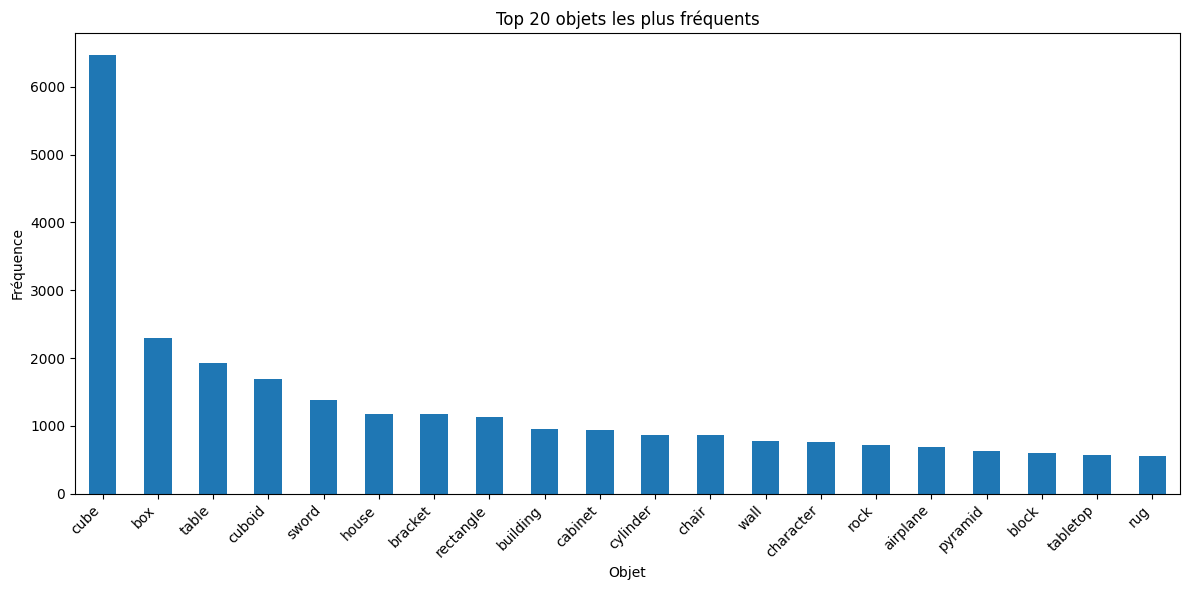

In [ ]:
df = pd.read_csv("classif.csv")

df['caption'] = df['caption'].astype(str).str.strip().str.lower()

caption_counts = df['caption'].value_counts()

# Print the number of times sword appears in caption
print(f"Number of times 'sword' appears in caption: {caption_counts.get('sword', 0)}")

print("Top 20 objets les plus fréquents :")
print(caption_counts.head(20))

print(f"\nNombre total d'objets uniques : {caption_counts.shape[0]}")

plt.figure(figsize=(12, 6))
caption_counts.head(20).plot(kind='bar')
plt.title("Top 20 objets les plus fréquents")
plt.xlabel("Objet")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Number of times 'sword' appears in caption: 0
Top 20 objets les plus fréquents :
Category
tumoredkidney        300
adrenalglandright    277
costa11left          277
costa10right         277
clavicleright        277
                    ... 
cheekright           233
vertebrae_c2         225
vertebrae_c4         223
vertebrae_c1         221
vertebrae_c3         206
Name: count, Length: 105, dtype: int64

Nombre total d'objets uniques : 303


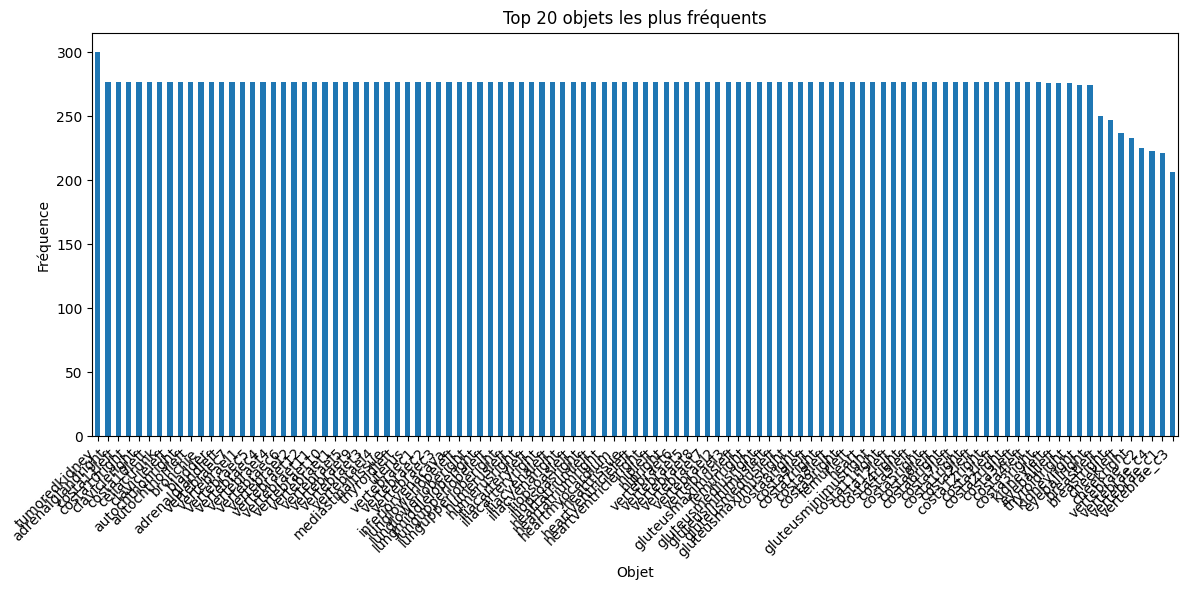

In [ ]:
df = pd.read_csv("MedShapeNet_list.csv")

df['Category'] = df['Category'].astype(str).str.strip().str.lower()

caption_counts = df['Category'].value_counts()

# Print the number of times sword appears in caption
print(f"Number of times 'sword' appears in caption: {caption_counts.get('vessel', 0)}")

print("Top 20 objets les plus fréquents :")

# print the number of objects presents between 500 and 100
print(caption_counts[(caption_counts >= 200) & (caption_counts <= 300)])

# print the number of scissors present in the dataset



print(f"\nNombre total d'objets uniques : {caption_counts.shape[0]}")

plt.figure(figsize=(12, 6))
caption_counts[(caption_counts >= 200) & (caption_counts <= 300)].plot(kind='bar')
plt.title("Top 20 objets les plus fréquents")
plt.xlabel("Objet")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import torch
torch.cuda.empty_cache()

## Data augmentation on instruments

In [ ]:
!pip install trimesh open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.3/709.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import trimesh
import copy
import random
from pathlib import Path
from trimesh import remesh
import open3d as o3d

In [ ]:
class MeshAugmenter:
    """Class for augmenting 3D mesh data of medical instruments with face count limits."""

    def __init__(self, input_dir, output_dir, max_faces=150):
        """
        Initialize the mesh augmenter.

        Args:
            input_dir: Directory containing original mesh files
            output_dir: Directory to save augmented meshes
            max_faces: Maximum number of faces allowed in output meshes
        """
        self.input_dir = Path(input_dir)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True, parents=True)
        self.meshes = []
        self.max_faces = max_faces
        self.load_meshes()

    def load_meshes(self):
        """Load all meshes from the input directory."""
        supported_extensions = ['.obj', '.stl', '.ply']

        for mesh_file in self.input_dir.iterdir():
            if mesh_file.suffix.lower() in supported_extensions:
                try:
                    mesh = trimesh.load(mesh_file)
                    # Simplify mesh if it has more than max_faces
                    if len(mesh.faces) > self.max_faces:
                        mesh = self.simplify_mesh(mesh, self.max_faces)
                        print(f"Simplified {mesh_file.name} to {len(mesh.faces)} faces")

                    self.meshes.append({
                        'name': mesh_file.stem,
                        'mesh': mesh,
                        'path': mesh_file
                    })
                    print(f"Loaded {mesh_file.name} with {len(mesh.faces)} faces")
                except Exception as e:
                    print(f"Error loading {mesh_file.name}: {e}")

        print(f"Loaded {len(self.meshes)} meshes in total")

    def rotate_mesh(self, mesh, angle_x=0, angle_y=0, angle_z=0):
        """Rotate mesh by given angles in degrees around each axis."""
        rotated = copy.deepcopy(mesh)

        # Convert to radians
        angle_x = np.radians(angle_x)
        angle_y = np.radians(angle_y)
        angle_z = np.radians(angle_z)

        # Create rotation matrices
        if angle_x != 0:
            rotated.apply_transform(trimesh.transformations.rotation_matrix(angle_x, [1, 0, 0]))
        if angle_y != 0:
            rotated.apply_transform(trimesh.transformations.rotation_matrix(angle_y, [0, 1, 0]))
        if angle_z != 0:
            rotated.apply_transform(trimesh.transformations.rotation_matrix(angle_z, [0, 0, 1]))

        return rotated

    def scale_mesh(self, mesh, scale_factors):
        """Scale mesh by given factors in x, y, z dimensions."""
        scaled = copy.deepcopy(mesh)
        # Create scaling matrix
        scale_matrix = np.eye(4)
        scale_matrix[0, 0] = scale_factors[0]
        scale_matrix[1, 1] = scale_factors[1]
        scale_matrix[2, 2] = scale_factors[2]

        scaled.apply_transform(scale_matrix)
        return scaled

    def print_mesh_metrics(self, mesh, label="Mesh"):
      print(f"{label} metrics:")
      print(f"  Vertices: {len(mesh.vertices)}")
      print(f"  Faces: {len(mesh.faces)}")
      print(f"  Surface area: {mesh.area:.2f}")
      print(f"  Volume: {mesh.volume:.2f}")
      bbox = mesh.bounding_box.extents
      print(f"  Bounding box: {bbox}")


    def add_noise(self, mesh, noise_factor=0.002):
        """Add random noise to vertex positions."""
        noisy = copy.deepcopy(mesh)

        # Get vertices
        vertices = noisy.vertices

        # Calculate bounding box dimensions for proportional noise
        bbox_size = np.max(vertices, axis=0) - np.min(vertices, axis=0)
        max_dim = np.max(bbox_size)

        # Add noise proportional to mesh size
        noise = np.random.normal(0, noise_factor * max_dim, vertices.shape)
        noisy.vertices = vertices + noise

        return noisy

    def bend_mesh(self, mesh, bend_factor=0.1, axis=1):
        """Apply a bending transformation along the specified axis."""
        bent = copy.deepcopy(mesh)
        vertices = bent.vertices

        # Get the bounding box dimensions
        bbox_min = np.min(vertices, axis=0)
        bbox_max = np.max(vertices, axis=0)
        bbox_center = (bbox_min + bbox_max) / 2

        # Normalize coordinates relative to bounding box center
        centered_verts = vertices - bbox_center

        # Determine main axis (usually longest dimension for retractors)
        main_axis = axis
        bend_axis = (main_axis + 1) % 3

        # Apply quadratic bending transformation
        length = bbox_max[main_axis] - bbox_min[main_axis]
        normalized_pos = (centered_verts[:, main_axis] / length) * 2

        # Apply bend effect
        bent.vertices[:, bend_axis] += bend_factor * length * (normalized_pos ** 2)

        return bent

    def simplify_mesh(self, mesh, target_faces):
      """
      Simplify a mesh using Open3D's quadric decimation.
      """
      try:
          # Convert Trimesh to Open3D
          mesh_o3d = o3d.geometry.TriangleMesh(
              o3d.utility.Vector3dVector(mesh.vertices),
              o3d.utility.Vector3iVector(mesh.faces)
          )

          # Ensure normals are computed
          mesh_o3d.compute_vertex_normals()

          # Apply simplification
          simplified = mesh_o3d.simplify_quadric_decimation(target_faces)

          # Optional second pass: vertex clustering
          voxel_size = max(simplified.get_max_bound() - simplified.get_min_bound()) / 100
          simplified = simplified.simplify_vertex_clustering(
              voxel_size=voxel_size,
              contraction=o3d.geometry.SimplificationContraction.Average
          )

          final_faces = np.asarray(simplified.triangles).shape[0]
          print(f"Simplified mesh from {len(mesh.faces)} to {final_faces} faces using Open3D")

          # Convert back to Trimesh
          simplified_trimesh = trimesh.Trimesh(
              vertices=np.asarray(simplified.vertices),
              faces=np.asarray(simplified.triangles)
          )

          return simplified_trimesh
      except Exception as e:
          print(f"Open3D simplification failed: {e}")
      return mesh  # fallback

    def modify_blade_width(self, mesh, width_factor=1.1):
        """
        Modify the width of the blade part of the retractor.
        For Langenbeck retractors, we assume the blade is along the widest dimension.
        """
        modified = copy.deepcopy(mesh)
        vertices = modified.vertices

        # Identify the blade region (simplified approach - assumes blade is at one end)
        # This is a heuristic and might need adjustment for specific meshes
        bbox_min = np.min(vertices, axis=0)
        bbox_max = np.max(vertices, axis=0)

        # Find the longest dimension (typically the main axis of the retractor)
        dims = bbox_max - bbox_min
        main_axis = np.argmax(dims)

        # Determine secondary axis (width direction)
        width_axis = (main_axis + 1) % 3

        # Find the blade region (assuming it's at one end of the main axis)
        # This is simplified and assumes the blade is at the maximum end of the main axis
        blade_threshold = bbox_min[main_axis] + dims[main_axis] * 0.7
        blade_mask = vertices[:, main_axis] > blade_threshold

        # Modify width of the blade
        if np.any(blade_mask):
            # Find center of the blade along width axis
            blade_center = (np.max(vertices[blade_mask, width_axis]) +
                           np.min(vertices[blade_mask, width_axis])) / 2

            # Scale vertices from center
            width_diff = vertices[blade_mask, width_axis] - blade_center
            vertices[blade_mask, width_axis] = blade_center + width_diff * width_factor

        return modified

    def generate_augmentations(self, num_augmentations=40):
      """Generate augmented versions of all loaded meshes."""
      augmented_count = 0

      for mesh_data in self.meshes:
          base_mesh = mesh_data['mesh']
          base_name = mesh_data['name']

          for i in range(num_augmentations):
              augmented = copy.deepcopy(base_mesh)

              # Random rotation
              if random.random() > 0.3:
                  angle_x = random.uniform(-15, 15)
                  angle_y = random.uniform(-15, 15)
                  angle_z = random.uniform(-15, 15)
                  augmented = self.rotate_mesh(augmented, angle_x, angle_y, angle_z)

              # Random scaling (subtle variations)
              if random.random() > 0.3:
                  scale_x = random.uniform(0.9, 1.1)
                  scale_y = random.uniform(0.9, 1.1)
                  scale_z = random.uniform(0.9, 1.1)
                  augmented = self.scale_mesh(augmented, (scale_x, scale_y, scale_z))

              # Add noise
              if random.random() > 0.5:
                  noise_factor = random.uniform(0.0005, 0.002)
                  augmented = self.add_noise(augmented, noise_factor)

              # Bend modification
              if random.random() > 0.7:
                  bend_factor = random.uniform(-0.1, 0.1)
                  augmented = self.bend_mesh(augmented, bend_factor)

              # Modify blade width
              if random.random() > 0.6:
                  width_factor = random.uniform(0.9, 1.2)
                  augmented = self.modify_blade_width(augmented, width_factor)

              # Ensure face count
              augmented = self.simplify_mesh(augmented, self.max_faces)

              # Print metrics
              #self.print_mesh_metrics(augmented, label=f"{base_name}_aug_{i+1}")

              # Check existing files to avoid overwriting
              existing_files = list(self.output_dir.glob(f"{base_name}_aug_*.obj"))
              next_index = len(existing_files) + 1

              output_path = self.output_dir / f"{base_name}_aug_{next_index}.obj"
              augmented.export(output_path)
              augmented_count += 1
              print(f"Saved {output_path.name} with {len(augmented.faces)} faces")

              if augmented_count % 10 == 0:
                  print(f"Generated {augmented_count} augmented meshes...")

      print(f"Successfully generated {augmented_count} augmented meshes in {self.output_dir}")

    def visualize_sample(self, original_idx=0, num_samples=3):
        """Visualize original mesh alongside some augmented versions."""
        try:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D

            if not self.meshes:
                print("No meshes loaded for visualization")
                return

            fig = plt.figure(figsize=(15, 5))

            # Plot original
            original = self.meshes[original_idx]['mesh']
            ax1 = fig.add_subplot(141, projection='3d')
            self._plot_mesh(ax1, original)
            ax1.set_title("Original")

            # Generate and plot some samples
            for i in range(num_samples):
                # Create random augmentation
                augmented = copy.deepcopy(original)

                # Apply random transformations
                angle_x = random.uniform(-15, 15)
                angle_y = random.uniform(-15, 15)
                angle_z = random.uniform(-15, 15)
                augmented = self.rotate_mesh(augmented, angle_x, angle_y, angle_z)

                scale_x = random.uniform(0.9, 1.1)
                scale_y = random.uniform(0.9, 1.1)
                scale_z = random.uniform(0.9, 1.1)
                augmented = self.scale_mesh(augmented, (scale_x, scale_y, scale_z))

                if random.random() > 0.5:
                    augmented = self.add_noise(augmented, 0.001)

                if random.random() > 0.5:
                    augmented = self.bend_mesh(augmented, random.uniform(-0.1, 0.1))

                # Plot
                ax = fig.add_subplot(1, 4, i+2, projection='3d')
                self._plot_mesh(ax, augmented)
                ax.set_title(f"Augmentation {i+1}")

            plt.tight_layout()
            plt.savefig(self.output_dir / "visualization.png")
            plt.close()
            print(f"Visualization saved to {self.output_dir / 'visualization.png'}")

        except ImportError:
            print("Matplotlib not available for visualization")

    def _plot_mesh(self, ax, mesh):
        """Helper to plot a mesh on a matplotlib 3D axis."""
        vertices = mesh.vertices
        faces = mesh.faces

        # Plot vertices
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], s=0.1, color='b')

        # Plot a subset of faces for better visualization
        sample_faces = faces[::20]  # Sample every 20th face to avoid overplotting

        for face in sample_faces:
            x = [vertices[face[0], 0], vertices[face[1], 0], vertices[face[2], 0], vertices[face[0], 0]]
            y = [vertices[face[0], 1], vertices[face[1], 1], vertices[face[2], 1], vertices[face[0], 1]]
            z = [vertices[face[0], 2], vertices[face[1], 2], vertices[face[2], 2], vertices[face[0], 2]]
            ax.plot(x, y, z, color='r', alpha=0.2)

        # Set equal aspect ratio
        ax.set_box_aspect([1, 1, 1])

        # Remove axis labels
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_zlabel('')


"""Main function to demonstrate augmentation."""

# Create augmenter
augmenter = MeshAugmenter('drive/MyDrive/Projet_DL_LlaMa-Mesh/dataset/stl/', 'drive/MyDrive/Projet_DL_LlaMa-Mesh/dataset/obj-fixed/')

# Generate augmentations
augmenter.generate_augmentations()

# print the metrics on the generated meshes
augmenter.print_mesh_metrics(augmenter.meshes[0]['mesh'], "Original mesh")

Simplified mesh from 776598 to 140 faces using Open3D
Simplified 024_LangenbeckRetractors.stl to 140 faces
Loaded 024_LangenbeckRetractors.stl with 140 faces
Simplified mesh from 399187 to 150 faces using Open3D
Simplified 023_LangenbeckRetractors.stl to 150 faces
Loaded 023_LangenbeckRetractors.stl with 150 faces
Simplified mesh from 199898 to 150 faces using Open3D
Simplified 029_LangenbeckRetractors.stl to 150 faces
Loaded 029_LangenbeckRetractors.stl with 150 faces
Simplified mesh from 498302 to 150 faces using Open3D
Simplified 027_LangenbeckRetractors.stl to 150 faces
Loaded 027_LangenbeckRetractors.stl with 150 faces
Simplified mesh from 506100 to 150 faces using Open3D
Simplified 026_LangenbeckRetractors.stl to 150 faces
Loaded 026_LangenbeckRetractors.stl with 150 faces
Simplified mesh from 506100 to 150 faces using Open3D
Simplified 025_LangenbeckRetractors.stl to 150 faces
Loaded 025_LangenbeckRetractors.stl with 150 faces
Loaded 6 meshes in total
Simplified mesh from 140 to

### Vertex quantization on a single data

In [ ]:
import numpy as np

def quantize_obj(input_obj_path, num_bins=64, output_txt_path=None):
    """
    1) Lit un OBJ, extrait les sommets (v x y z) et les faces (f i j k).
    2) Met à l'échelle isotrope le nuage de points pour préserver les proportions
       et que tout tienne dans un cube [-0.5, +0.5].
    3) Remappe ensuite dans [0, num_bins].
    4) Arrondit au plus proche entier (quantification).
    5) Reconstruit le texte avec <start_of_mesh> et <end_of_mesh>.
    """

    # ─── 1. Lecture du OBJ ────────────────────────────────────────────────
    verts, faces = [], []
    with open(input_obj_path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                _, x, y, z = line.strip().split()
                verts.append([float(x), float(y), float(z)])
            elif line.startswith('f '):
                faces.append(line.strip())

    verts = np.array(verts)  # shape (N,3)
    if verts.size == 0:
        raise ValueError("Pas de sommets trouvés dans " + input_obj_path)

    # ─── 2. Calcul des bornes globales ────────────────────────────────────
    mins = verts.min(axis=0)   # [min_x, min_y, min_z]
    maxs = verts.max(axis=0)   # [max_x, max_y, max_z]
    centers = (mins + maxs) / 2.0
    ranges = maxs - mins
    scale = ranges.max()  # longueur maximale (pour garder les proportions)

    if scale == 0:
        scale = 1.0  # éviter division par zéro si objet dégénéré

    # ─── 3. Mise à l'échelle isotrope et centrage ─────────────────────────
    # On centre autour de 0, et scale dans [-0.5, +0.5]
    normalized = (verts - centers) / scale  # [-0.5, +0.5] si forme remplie

    # Remap dans [0, num_bins]
    scaled = (normalized + 0.5) * num_bins

    # ─── 4. Quantification ────────────────────────────────────────────────
    quantized = np.rint(scaled).astype(int)

    # Clamp pour s'assurer qu'on reste dans [0, num_bins]
    quantized = np.clip(quantized, 0, num_bins)

    # ─── 5. Reconstruction du texte quantifié ─────────────────────────────
    lines = ["<start_of_mesh>"]
    for qx, qy, qz in quantized:
        lines.append(f"v {qx} {qy} {qz}")
    lines.extend(faces)
    lines.append("<end_of_mesh>")

    output_text = "\n".join(lines)

    return output_text

# Example usage
input_path = 'fine-tuned-llama-mesh/dataset/femur/028262_femurright.obj'
quantized_text = quantize_obj(input_path)
print(quantized_text)


<start_of_mesh>
v 40 26 1
v 37 29 0
v 40 34 0
v 45 29 1
v 35 33 1
v 44 35 2
v 35 24 3
v 32 29 4
v 39 21 8
v 43 23 4
v 49 28 6
v 33 37 7
v 40 39 5
v 46 23 10
v 34 23 13
v 46 38 10
v 30 30 10
v 31 36 10
v 38 40 11
v 49 32 13
v 28 25 12
v 31 33 14
v 42 24 17
v 27 17 11
v 23 17 12
v 26 20 13
v 23 23 12
v 18 23 13
v 24 28 13
v 40 38 16
v 28 13 15
v 31 16 14
v 20 28 17
v 18 16 18
v 27 21 20
v 46 28 17
v 22 31 15
v 44 35 18
v 27 31 18
v 37 34 17
v 21 13 19
v 30 17 19
v 15 22 21
v 35 24 18
v 42 30 18
v 28 15 27
v 38 28 20
v 32 22 24
v 33 33 25
v 30 17 25
v 16 26 26
v 25 32 29
v 22 16 28
v 19 29 31
v 17 20 26
v 36 29 29
v 32 22 30
v 30 34 34
v 24 21 37
v 19 23 31
v 39 30 34
v 33 31 35
v 37 24 34
v 29 24 38
v 22 34 38
v 37 28 38
v 27 39 43
v 22 30 49
v 21 33 46
v 30 40 48
v 23 44 52
v 27 29 49
v 30 31 47
v 30 41 63
v 20 46 64
v 26 51 63
v 30 47 64
v 28 37 64
v 20 42 64
f 70 76 77
f 68 78 79
f 71 75 76
f 68 72 78
f 72 73 78
f 65 75 71
f 62 74 73
f 62 70 74
f 59 72 68
f 64 73 72
f 67 76 70
f 62 73

## stl exploration

In [ ]:
!pip install -q trimesh open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.0/712.0 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.2 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/hugoaslm/fine-tuned-llama-mesh

Cloning into 'fine-tuned-llama-mesh'...
remote: Enumerating objects: 53045, done.
remote: Counting objects: 100% (2055/2055), done.
remote: Compressing objects: 100% (2050/2050), done.
remote: Total 53045 (delta 12), reused 2047 (delta 5), pack-reused 50990 (from 2)
Receiving objects: 100% (53045/53045), 718.77 MiB | 19.68 MiB/s, done.
Resolving deltas: 100% (238/238), done.
Updating files: 100% (62344/62344), done.


In [ ]:
import trimesh
import numpy as np
import open3d as o3d
import os
import io

def quantize_obj(input_obj_path, output_quantized_txt_path="output_quantized_mesh.obj", num_bins=64):
    """
    Quantifie les sommets d'un fichier OBJ et sauvegarde le résultat dans un fichier texte.
    Le fichier texte contiendra :
      - les sommets quantifiés (coordonnées entières dans [0, num_bins])
      - les faces (inchangées) telles qu’elles étaient dans le OBJ d’origine.
    Retourne également le contenu quantifié sous forme de chaîne.
    """
    verts_float = []
    faces_lines = []

    # 1. Lecture du fichier OBJ : on récupère séparément les sommets et les lignes de faces
    with open(input_obj_path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                parts = line.strip().split()
                verts_float.append([float(parts[1]), float(parts[2]), float(parts[3])])
            elif line.startswith('f '):
                faces_lines.append(line.strip())

    verts = np.array(verts_float)
    if verts.size == 0:
        raise ValueError(f"Aucun sommet trouvé dans '{input_obj_path}'")

    # 2. Calcul de la boîte englobante pour normaliser
    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    centers = (mins + maxs) / 2.0
    ranges = maxs - mins
    scale = ranges.max()
    if scale == 0:
        scale = 1.0  # éviter division par zéro

    # 3. Normalisation dans [-0.5, 0.5], puis mise à l'échelle dans [0, num_bins]
    normalized = (verts - centers) / scale        # sommets dans [-0.5, 0.5]
    scaled = (normalized + 0.5) * num_bins       # sommets dans [0, num_bins]
    quantized = np.rint(scaled).astype(int)       # arrondi aux entiers
    quantized = np.clip(quantized, 0, num_bins)  # on s'assure de ne pas sortir de l’intervalle

    # 4. Reconstruction des lignes "v x y z" pour les sommets quantifiés
    output_lines = []
    for qx, qy, qz in quantized:
        output_lines.append(f"v {qx} {qy} {qz}")

    # 5. On ajoute ensuite les mêmes lignes "f ..." qu’à l’origine
    output_lines.extend(faces_lines)

    # 6. Sauvegarde dans le fichier texte de sortie
    with open(output_quantized_txt_path, "w") as f:
        for line in output_lines:
            f.write(line + "\n")

    print(f"Maillage quantifié (format texte) sauvegardé dans : '{output_quantized_txt_path}'")
    return "\n".join(output_lines)


def simplify_mesh(mesh, target_faces):
    """
    Simplify a mesh using Open3D's quadric decimation.
    """
    try:
        # Convert Trimesh to Open3D
        mesh_o3d = o3d.geometry.TriangleMesh(
            o3d.utility.Vector3dVector(mesh.vertices),
            o3d.utility.Vector3iVector(mesh.faces)
        )

        # Ensure normals are computed
        mesh_o3d.compute_vertex_normals()

        # Apply simplification
        simplified = mesh_o3d.simplify_quadric_decimation(target_faces)

        # Optional second pass: vertex clustering
        voxel_size = max(simplified.get_max_bound() - simplified.get_min_bound()) / 100
        simplified = simplified.simplify_vertex_clustering(
            voxel_size=voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average
        )

        final_faces = np.asarray(simplified.triangles).shape[0]
        print(f"Simplified mesh from {len(mesh.faces)} to {final_faces} faces using Open3D")

        # Convert back to Trimesh
        simplified_trimesh = trimesh.Trimesh(
            vertices=np.asarray(simplified.vertices),
            faces=np.asarray(simplified.triangles)
        )

        return simplified_trimesh

    except Exception as e:
        print(f"Open3D simplification failed: {e}")
        return mesh  # fallback if simplification échoue


def process_and_visualize_mesh(input_file_path, target_faces=300, quantization_bins=64):
    """
    Charge un fichier maillage (STL, GLB, OBJ, etc.), le simplifie avec Open3D, le quantifie
    et tente de l’afficher. Les fichiers de sortie seront nommés en fonction du fichier d'entrée.
    """
    if not os.path.exists(input_file_path):
        print(f"Erreur : Le fichier '{input_file_path}' n'a pas été trouvé.")
        return

    file_name_without_ext = os.path.splitext(os.path.basename(input_file_path))[0]
    output_quantized_txt_file = f"sport_ball_obj/{file_name_without_ext}_quantized_mesh.obj"
    temp_obj_path = f"temp_{file_name_without_ext}_simplified_for_quantization.obj"

    print(f"\n--- Traitement du fichier : '{input_file_path}' ---")
    print(f"1. Chargement du fichier : '{input_file_path}'")
    try:
        mesh = trimesh.load_mesh(input_file_path)
    except Exception as e:
        print(f"Erreur lors du chargement du fichier : {e}")
        return

    print(f"   Nombre de faces initial : {len(mesh.faces)}")

    # Nettoyage basique
    mesh.process()

    # 2. Simplification du maillage avec Open3D
    if len(mesh.faces) > target_faces:
        print(f"\n2. Simplification du maillage à {target_faces} faces cibles…")
        mesh_simplified = simplify_mesh(mesh, target_faces)
        print(f"   Nombre de faces après simplification : {len(mesh_simplified.faces)}")
    else:
        print(f"\n2. Le maillage a déjà moins de {target_faces} faces ({len(mesh.faces)}). Pas de simplification.")
        mesh_simplified = mesh.copy()

    # 3. Export temporaire en OBJ pour la quantification
    print(f"\n3. Exportation du maillage simplifié vers '{temp_obj_path}' (temporaire)")
    try:
        mesh_simplified.export(temp_obj_path)
    except Exception as e:
        print(f"   Échec de l’export OBJ : {e}")
        return

    # 4. Quantification des sommets via la fonction quantize_obj
    print(f"\n4. Quantification des sommets (bins = {quantization_bins})")
    try:
        quantized_obj_data_string = quantize_obj(
            temp_obj_path,
            output_quantized_txt_path=output_quantized_txt_file,
            num_bins=quantization_bins
        )
    except ValueError as ve:
        print(f"Erreur de quantification : {ve}")
        if os.path.exists(temp_obj_path):
            os.remove(temp_obj_path)
        return
    except Exception as e:
        print(f"Erreur inattendue pendant la quantification : {e}")
        if os.path.exists(temp_obj_path):
            os.remove(temp_obj_path)
        return

    # 5. Chargement du maillage quantifié (à partir de la chaîne OBJ) pour la visualisation
    print(f"\n5. Chargement du maillage quantifié pour visualisation…")
    try:
        quantized_file_obj = io.StringIO(quantized_obj_data_string)
        final_mesh = trimesh.load_mesh(quantized_file_obj, file_type='obj')
    except Exception as e:
        print(f"Erreur lors du chargement du maillage quantifié : {e}")
        print("Contenu partiel des données OBJ quantifiées :")
        print("---DEBUT---")
        print(quantized_obj_data_string[:1000])
        print("---FIN (premiers 1000 caractères)---")
        if os.path.exists(temp_obj_path):
            os.remove(temp_obj_path)
        return

    # 6. Affichage du maillage final (si l’environnement le permet)
    print(f"\n6. Visualisation du maillage final quantifié…")
    try:
        final_mesh.show()
    except Exception as e:
        print(f"   Échec de la visualisation : {e}")
        print("   Assurez-vous d’avoir un environnement graphique (ex. pyglet) configuré.")
        print(f"   Le maillage quantifié est disponible dans '{output_quantized_txt_file}'.")

    # 7. Nettoyage du fichier OBJ temporaire
    print(f"\n7. Suppression du fichier temporaire '{temp_obj_path}'…")
    if os.path.exists(temp_obj_path):
        os.remove(temp_obj_path)
        print("   Supprimé.")

    print(f"--- Traitement de '{input_file_path}' terminé. ---")


def process_folder(folder_path, target_faces=300, quantization_bins=64):
    """
    Parcourt tous les fichiers dans un dossier donné et exécute
    process_and_visualize_mesh sur chaque fichier pris en charge.
    """
    if not os.path.isdir(folder_path):
        print(f"Erreur : Le chemin '{folder_path}' n'est pas un dossier valide.")
        return

    supported_extensions = ['.stl', '.obj', '.glb', '.gltf'] # Add or remove extensions as needed

    print(f"Démarrage du traitement des fichiers dans le dossier : '{folder_path}'")
    for item in os.listdir(folder_path):
        full_path = os.path.join(folder_path, item)
        if os.path.isfile(full_path):
            file_extension = os.path.splitext(item)[1].lower()
            if file_extension in supported_extensions:
                process_and_visualize_mesh(full_path, target_faces, quantization_bins)
            else:
                print(f"Skipping '{item}' : extension '{file_extension}' non prise en charge.")
        else:
            print(f"Skipping '{item}' : ce n'est pas un fichier.")
    print(f"\nTraitement de tous les fichiers du dossier terminé.")


if __name__ == "__main__":
    # Example usage:
    # 1. To process a single file (as in your original code)
    # stl_file_path = "Simple soccer football.glb"
    # process_and_visualize_mesh(stl_file_path, target_faces=200, quantization_bins=64)

    # 2. To process all supported files in a specific folder
    input_folder_path = 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj'


    process_folder(input_folder_path, target_faces=300, quantization_bins=64)

Démarrage du traitement des fichiers dans le dossier : 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj'

--- Traitement du fichier : 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj/026_LangenbeckRetractors_aug_40.obj' ---
1. Chargement du fichier : 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj/026_LangenbeckRetractors_aug_40.obj'
   Nombre de faces initial : 298

2. Le maillage a déjà moins de 300 faces (298). Pas de simplification.

3. Exportation du maillage simplifié vers 'temp_026_LangenbeckRetractors_aug_40_simplified_for_quantization.obj' (temporaire)

4. Quantification des sommets (bins = 64)
Erreur inattendue pendant la quantification : [Errno 2] No such file or directory: 'sport_ball_obj/026_LangenbeckRetractors_aug_40_quantized_mesh.obj'

--- Traitement du fichier : 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj/023_LangenbeckRetractors_aug_10.obj' ---
1. Chargement du fichier : 'fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj/02

KeyboardInterrupt: 

In [ ]:
# save sport_ball_obj folder in a zip file
import shutil
shutil.make_archive("sport_ball_obj", 'zip', "sport_ball_obj")

'/content/sport_ball_obj.zip'

In [ ]:
# display mesh
import trimesh
mesh = trimesh.load_mesh("fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj/023_LangenbeckRetractors_aug_1.obj")
mesh.show()

Nombre de faces : 300


## Create dataset

In [ ]:
import os
import json
import numpy as np

def quantize_obj(input_obj_path, num_bins=64):
    verts, faces = [], []
    with open(input_obj_path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                _, x, y, z = line.strip().split()
                verts.append([float(x), float(y), float(z)])
            elif line.startswith('f '):
                faces.append(line.strip())

    verts = np.array(verts)
    if verts.size == 0:
        raise ValueError("Pas de sommets trouvés dans " + input_obj_path)

    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    centers = (mins + maxs) / 2.0
    ranges = maxs - mins
    scale = ranges.max()

    if scale == 0:
        scale = 1.0

    normalized = (verts - centers) / scale
    scaled = (normalized + 0.5) * num_bins
    quantized = np.rint(scaled).astype(int)
    quantized = np.clip(quantized, 0, num_bins)

    lines = []
    for qx, qy, qz in quantized:
        lines.append(f"v {qx} {qy} {qz}")
    lines.extend(faces)

    # save into a txt file the output
    with open("output_old.txt", "w") as f:
      for line in lines:
          f.write(line + "\n")

    return "\n".join(lines)

# === PARAMÈTRES ===
input_path = "fine-tuned-llama-mesh/dataset/femur"
prompt_text = "Create a 3D model of a femur in obj format"
train_output_json = "dataset-femur_old.json"

# === CONSTRUCTION DU DATASET ===
dataset = []

# Parcours de tous les fichiers OBJ du dossier
obj_files = sorted([f for f in os.listdir(input_path) if f.endswith(".obj")])

for idx, filename in enumerate(obj_files):
    file_path = os.path.join(input_path, filename)
    try:
        quantized_mesh = quantize_obj(file_path)
    except Exception as e:
        print(f"Erreur avec le fichier {filename}: {e}")
        continue

    entry = {
        "prompt": prompt_text,
        "assistant": quantized_mesh
    }
    dataset.append(entry)

    print(f"[{idx+1}/{len(obj_files)}] Processed: {filename}")

# === SAUVEGARDE ===
with open(train_output_json, "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)
print(f"Dataset TRAIN sauvegardé dans {train_output_json} ({len(dataset)} entrées)")

[1/1527] Processed: 000442_femurleft.obj
[2/1527] Processed: 000442_femurright.obj
[3/1527] Processed: 001313_femurleft.obj
[4/1527] Processed: 001313_femurright.obj
[5/1527] Processed: 002056_femurleft.obj
[6/1527] Processed: 002056_femurright.obj
[7/1527] Processed: 002459_femurleft.obj
[8/1527] Processed: 002459_femurright.obj
[9/1527] Processed: 002737_femurleft.obj
[10/1527] Processed: 002737_femurright.obj
[11/1527] Processed: 003164_femurleft.obj
[12/1527] Processed: 003164_femurright.obj
[13/1527] Processed: 004329_femurleft.obj
[14/1527] Processed: 004329_femurright.obj
[15/1527] Processed: 005001_femurleft.obj
[16/1527] Processed: 005001_femurright.obj
[17/1527] Processed: 005703_femurleft.obj
[18/1527] Processed: 005703_femurright.obj
[19/1527] Processed: 006412_femurleft.obj
[20/1527] Processed: 006412_femurright.obj
[21/1527] Processed: 006919_femurleft.obj
[22/1527] Processed: 006919_femurright.obj
[23/1527] Processed: 006968_femurleft.obj
[24/1527] Processed: 006968_femu

In [ ]:
# dataset preprocessed without augmentation

def quantize_obj(input_obj_path, num_bins=64):
    verts, faces = [], []

    with open(input_obj_path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                _, x, y, z = line.strip().split()
                verts.append([float(x), float(y), float(z)])  # OBJ format: x y z
            elif line.startswith('f '):
                # Support only vertex indices (1-based)
                indices = [int(part.split('/')[0]) - 1 for part in line.strip().split()[1:]]
                if len(indices) >= 3:
                    faces.append(indices)

    verts = np.array(verts)
    if verts.size == 0:
        raise ValueError(f"Pas de sommets trouvés dans {input_obj_path}")

    # Normalize and quantize
    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    centers = (mins + maxs) / 2.0
    scale = (maxs - mins).max() or 1.0

    normalized = (verts - centers) / scale
    scaled = (normalized + 0.5) * num_bins
    quantized = np.rint(scaled).astype(int)
    quantized = np.clip(quantized, 0, num_bins)

    # === STEP 1: Sort vertices by z → y → x ===
    zyx_coords = quantized[:, [2, 1, 0]]  # z y x
    sort_indices = np.lexsort((zyx_coords[:, 2], zyx_coords[:, 1], zyx_coords[:, 0]))
    sorted_verts = quantized[sort_indices]

    # Map old vertex index → new sorted index
    old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(sort_indices)}

    # === STEP 2: Remap faces, rotate, and sort ===
    processed_faces = []
    for face in faces:
        # Remap using sorted vertex indices
        remapped = [old_to_new[idx] for idx in face]
        # Rotate to put the lowest index first
        min_pos = remapped.index(min(remapped))
        rotated = remapped[min_pos:] + remapped[:min_pos]
        processed_faces.append(rotated)

    # Sort faces lexicographically (lowest index, then next, etc.)
    processed_faces.sort()

    # === STEP 3: Output lines in correct format ===
    lines = []
    for v in sorted_verts:
        z, y, x = v[2], v[1], v[0]  # Output in z y x format
        lines.append(f"v {z} {y} {x}")
    for face in processed_faces:
        lines.append("f " + " ".join(str(idx + 1) for idx in face))  # OBJ indices are 1-based

    # save into a txt file the output
    with open("output.txt", "w") as f:
      for line in lines:
          f.write(line + "\n")

    return "\n".join(lines)

# === PARAMÈTRES ===
input_path = "fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj-150"
prompt_text = "Create a 3D model of a langenbeck rectractor in obj format"
train_output_json = "dataset-langenbeck.json"

# === CONSTRUCTION DU DATASET ===
dataset = []

# Parcours de tous les fichiers OBJ du dossier
obj_files = sorted([f for f in os.listdir(input_path) if f.endswith(".obj")])

for idx, filename in enumerate(obj_files):
    file_path = os.path.join(input_path, filename)
    try:
        quantized_mesh = quantize_obj(file_path)
    except Exception as e:
        print(f"Erreur avec le fichier {filename}: {e}")
        continue

    entry = {
        "prompt": prompt_text,
        "assistant": quantized_mesh
    }
    dataset.append(entry)

    print(f"[{idx+1}/{len(obj_files)}] Processed: {filename}")

# === SAUVEGARDE ===
with open(train_output_json, "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)
print(f"Dataset TRAIN sauvegardé dans {train_output_json} ({len(dataset)} entrées)")

[1/240] Processed: 023_LangenbeckRetractors_aug_1.obj
[2/240] Processed: 023_LangenbeckRetractors_aug_10.obj
[3/240] Processed: 023_LangenbeckRetractors_aug_11.obj
[4/240] Processed: 023_LangenbeckRetractors_aug_12.obj
[5/240] Processed: 023_LangenbeckRetractors_aug_13.obj
[6/240] Processed: 023_LangenbeckRetractors_aug_14.obj
[7/240] Processed: 023_LangenbeckRetractors_aug_15.obj
[8/240] Processed: 023_LangenbeckRetractors_aug_16.obj
[9/240] Processed: 023_LangenbeckRetractors_aug_17.obj
[10/240] Processed: 023_LangenbeckRetractors_aug_18.obj
[11/240] Processed: 023_LangenbeckRetractors_aug_19.obj
[12/240] Processed: 023_LangenbeckRetractors_aug_2.obj
[13/240] Processed: 023_LangenbeckRetractors_aug_20.obj
[14/240] Processed: 023_LangenbeckRetractors_aug_21.obj
[15/240] Processed: 023_LangenbeckRetractors_aug_22.obj
[16/240] Processed: 023_LangenbeckRetractors_aug_23.obj
[17/240] Processed: 023_LangenbeckRetractors_aug_24.obj
[18/240] Processed: 023_LangenbeckRetractors_aug_25.obj
[19

### Verify dataset quality

In [ ]:
def save_mesh_from_llama_output(output_str, output_path):
    """
    Convertit un mesh généré par LLaMA-Mesh (avec \n littéraux) en .obj
    """
    # Nettoyage : transformer les '\n' littéraux en vraies lignes
    output_str = output_str.replace("\\n", "\n").strip()

    # Écriture dans un fichier .obj
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(output_str)

    print(f"✅ Mesh sauvegardé dans : {output_path}")


In [ ]:
import json

with open("dataset-femur-rotated.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

for i, entry in enumerate(dataset):
    obj_filename = f"quality_dataset_rotated/output_mesh_{i+1:03d}.obj"
    save_mesh_from_llama_output(entry["assistant"], obj_filename)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1109.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1110.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1111.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1112.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1113.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1114.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1115.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1116.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1117.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1118.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1119.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1120.obj
✅ Mesh sauvegardé dans : quality_dataset_rotated/output_mesh_1121.obj
✅ Mesh sauve

In [ ]:
# save the folder in zip
import shutil
shutil.make_archive("quality_dataset_rotated", 'zip', "quality_dataset_rotated")

'/content/quality_dataset_rotated.zip'

### Rotated dataset

In [ ]:
import os
import json
import numpy as np

def apply_fixed_y_rotation(verts, angle_deg):
    angle_rad = np.radians(angle_deg)
    rot_matrix = np.array([
        [np.cos(angle_rad), 0, np.sin(angle_rad)],
        [0, 1, 0],
        [-np.sin(angle_rad), 0, np.cos(angle_rad)]
    ])
    return verts @ rot_matrix.T

def apply_uniform_scale(verts, scale_factor):
    """Applies uniform scaling to vertices."""
    return verts * scale_factor

def quantize_obj(verts, faces, num_bins=64):
    # Normalisation
    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    centers = (mins + maxs) / 2.0
    scale = (maxs - mins).max() or 1.0

    normalized = (verts - centers) / scale
    scaled = (normalized + 0.5) * num_bins
    quantized = np.rint(scaled).astype(int)
    quantized = np.clip(quantized, 0, num_bins)

    # Tri z-y-x
    zyx = quantized[:, [2, 1, 0]]
    sort_idx = np.lexsort((zyx[:, 2], zyx[:, 1], zyx[:, 0]))
    sorted_verts = quantized[sort_idx]
    old_to_new = {old: new for new, old in enumerate(sort_idx)}

    # Faces remappées, tournées, triées
    processed_faces = []
    for face in faces:
        remapped = [old_to_new[idx] for idx in face]
        min_pos = remapped.index(min(remapped))
        rotated = remapped[min_pos:] + remapped[:min_pos]
        processed_faces.append(rotated)
    processed_faces.sort()

    # Format texte
    lines = [f"v {v[2]} {v[1]} {v[0]}" for v in sorted_verts]
    for face in processed_faces:
        lines.append("f " + " ".join(str(i + 1) for i in face))
    return "\n".join(lines)

def load_obj(path):
    verts, faces = [], []
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                _, x, y, z = line.strip().split()
                verts.append([float(x), float(y), float(z)])
            elif line.startswith('f '):
                indices = [int(part.split('/')[0]) - 1 for part in line.strip().split()[1:]]
                if len(indices) >= 3:
                    faces.append(indices)
    return np.array(verts), faces

# === PARAMS ===
input_path = "fine-tuned-llama-mesh/dataset/langenbeck_retractors/obj"
prompt_text = "Create a 3D model of a langenbeck retractor in obj format" # Changed prompt for sport balls
train_output_json = "dataset-langen_augmented.json" # Changed output filename

dataset = []
obj_files = sorted([f for f in os.listdir(input_path) if f.endswith(".obj")])

# Define augmentation parameters
rotation_angles = np.arange(0, 360, 90)
# 3 uniform scaling factors : smaller, original size, larger
scale_factors = [0.9, 1.0, 1.1]

total_augmentations_per_object = len(rotation_angles) * len(scale_factors)


for idx, filename in enumerate(obj_files):
    file_path = os.path.join(input_path, filename)
    try:
        verts, faces = load_obj(file_path)
    except Exception as e:
        print(f"Error with file {filename}: {e}")
        continue

    current_object_augmentations = 0
    for angle in rotation_angles:
        rotated_verts = apply_fixed_y_rotation(verts, angle)

        for scale_factor in scale_factors:
            scaled_verts = apply_uniform_scale(rotated_verts, scale_factor)

            try:
                mesh_str = quantize_obj(scaled_verts, faces)
            except Exception as e:
                print(f"Quantization error for {filename} with angle {angle}° and scale {scale_factor}: {e}")
                continue

            entry = {
                "prompt": prompt_text,
                "assistant": mesh_str
            }
            dataset.append(entry)
            current_object_augmentations += 1

    print(f"[{idx+1}/{len(obj_files)}] {filename} → {current_object_augmentations} augmentations added")

# SAUVEGARDE
with open(train_output_json, "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)

print(f"\nFinal dataset saved with {len(dataset)} entries (from {len(obj_files)} meshes). Each object was augmented {total_augmentations_per_object} times.")

[1/243] 023_LangenbeckRetractors_aug_1.obj → 12 augmentations added
[2/243] 023_LangenbeckRetractors_aug_10.obj → 12 augmentations added
[3/243] 023_LangenbeckRetractors_aug_11.obj → 12 augmentations added
[4/243] 023_LangenbeckRetractors_aug_12.obj → 12 augmentations added
[5/243] 023_LangenbeckRetractors_aug_13.obj → 12 augmentations added
[6/243] 023_LangenbeckRetractors_aug_14.obj → 12 augmentations added
[7/243] 023_LangenbeckRetractors_aug_15.obj → 12 augmentations added
[8/243] 023_LangenbeckRetractors_aug_16.obj → 12 augmentations added
[9/243] 023_LangenbeckRetractors_aug_17.obj → 12 augmentations added
[10/243] 023_LangenbeckRetractors_aug_18.obj → 12 augmentations added
[11/243] 023_LangenbeckRetractors_aug_19.obj → 12 augmentations added
[12/243] 023_LangenbeckRetractors_aug_2.obj → 12 augmentations added
[13/243] 023_LangenbeckRetractors_aug_20.obj → 12 augmentations added
[14/243] 023_LangenbeckRetractors_aug_21.obj → 12 augmentations added
[15/243] 023_LangenbeckRetracto

## Categorize femurs

In [ ]:
import os
import re
import shutil

# === PARAMETERS ===
input_path = "fine-tuned-llama-mesh/dataset/femur"  # Path to the folder containing the OBJ files
output_path = "categorized_femurs"  # Path to the directory where category folders will be created

# Create the output directory if it doesn't exist
if not os.path.exists(output_path):
    os.makedirs(output_path)

# === COUNTING AND COPYING FEMURS BY PATTERN ===
femur_patterns = {}

# List all OBJ files in the folder
obj_files = sorted([f for f in os.listdir(input_path) if f.endswith(".obj")])

for filename in obj_files:
    lower_filename = filename.lower()
    category_folder = "" # Initialize

    # Match 099815_femurleft_obj or 099815_femurright_obj
    if re.search(r"femurleft.obj$", lower_filename):
        category = "femurleft"
        femur_patterns[category] = femur_patterns.get(category, 0) + 1
        category_folder = os.path.join(output_path, category)
    elif re.search(r"femurright.obj$", lower_filename):
        category = "femurright"
        femur_patterns[category] = femur_patterns.get(category, 0) + 1
        category_folder = os.path.join(output_path, category)

    # Match  femur_left.nii or femur_right.nii
    elif "femur_left.nii" in lower_filename:
        category = "left_other"
        femur_patterns[category] = femur_patterns.get(category, 0) + 1
        category_folder = os.path.join(output_path, "left_other")
    elif "femur_right.nii" in lower_filename:
        category = "right_other"
        femur_patterns[category] = femur_patterns.get(category, 0) + 1
        category_folder = os.path.join(output_path, "right_other")
    else:
        category = "non_femur"
        femur_patterns[category] = femur_patterns.get(category, 0) + 1
        category_folder = os.path.join(output_path, "non_femur")

    # Create the category folder if it doesn't exist
    if not os.path.exists(category_folder):
        os.makedirs(category_folder)

    # Copy the OBJ file to the category folder
    source_file = os.path.join(input_path, filename)
    destination_file = os.path.join(category_folder, filename)
    try:
        shutil.copy(source_file, destination_file)
        print(f"Copied {filename} to {category_folder}")
    except Exception as e:
        print(f"Error copying {filename}: {e}")

# === DISPLAY FEMUR COUNTS BY PATTERN ===
print("--- Number of files per category ---")
for pattern, count in femur_patterns.items():
    print(f"{pattern.capitalize()}: {count}")


Copied 000442_femurleft.obj to categorized_femurs/femurleft
Copied 000442_femurright.obj to categorized_femurs/femurright
Copied 001313_femurleft.obj to categorized_femurs/femurleft
Copied 001313_femurright.obj to categorized_femurs/femurright
Copied 002056_femurleft.obj to categorized_femurs/femurleft
Copied 002056_femurright.obj to categorized_femurs/femurright
Copied 002459_femurleft.obj to categorized_femurs/femurleft
Copied 002459_femurright.obj to categorized_femurs/femurright
Copied 002737_femurleft.obj to categorized_femurs/femurleft
Copied 002737_femurright.obj to categorized_femurs/femurright
Copied 003164_femurleft.obj to categorized_femurs/femurleft
Copied 003164_femurright.obj to categorized_femurs/femurright
Copied 004329_femurleft.obj to categorized_femurs/femurleft
Copied 004329_femurright.obj to categorized_femurs/femurright
Copied 005001_femurleft.obj to categorized_femurs/femurleft
Copied 005001_femurright.obj to categorized_femurs/femurright
Copied 005703_femurleft.

# Training

In [ ]:
!git clone -q https://github.com/hugoaslm/fine-tuned-llama-mesh

In [ ]:
!pip install -q bitsandbytes
!pip install -q peft
!pip install -q unsloth unsloth_zoo
!pip install -q trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Making sure we are running on the GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda'

In [ ]:
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoTokenizer,
    TrainingArguments,
)
from trl import SFTTrainer

model_name = "Zhengyi/LLaMA-Mesh"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/51.3k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

In [ ]:
# Quantization configuration
bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
)

# Load the model on the GPU and quantize it on the fly
model = AutoModelForCausalLM.from_pretrained(
          model_name,
          quantization_config=bnb_config
)
model.to(device)

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((409

In [ ]:
# Cast some modules of the model to float32 to improve training stability
model = prepare_model_for_kbit_training(model)
# Configure the pad token in the model
model.config.pad_token_id = tokenizer.pad_token_id
# Gradient checkpointing is used by default but not compatible with caching
model.config.use_cache = False

In [ ]:
from datasets import load_dataset
dataset = load_dataset("json", data_files="dataset-langen_augmented.json")["train"]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

def formatting_prompts_func(examples):
    texts = []
    for prompt, assistant in zip(examples["prompt"], examples["assistant"]):
        conversation = [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": assistant}
        ]
        text = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return { "text": texts }

<ipython-input-8-2141983656>:1: UserWarning: WARNING: Unsloth should be imported before trl, transformers, peft to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth.chat_templates import get_chat_template


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Model does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


In [ ]:
from unsloth.chat_templates import standardize_sharegpt
dataset = standardize_sharegpt(dataset)
dataset = dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/2916 [00:00<?, ? examples/s]

In [ ]:
dataset[1]["text"]

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nCreate a 3D model of a langenbeck retractor in obj format<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nv 21 58 32\nv 21 58 33\nv 21 60 31\nv 21 60 32\nv 21 61 32\nv 22 56 31\nv 22 58 31\nv 22 59 31\nv 22 59 32\nv 22 63 31\nv 22 63 33\nv 23 51 33\nv 23 54 32\nv 23 54 33\nv 23 61 32\nv 23 62 33\nv 23 63 31\nv 24 51 31\nv 24 52 31\nv 24 52 33\nv 24 62 31\nv 24 64 32\nv 25 47 34\nv 25 52 32\nv 25 62 33\nv 26 45 32\nv 26 45 33\nv 26 64 33\nv 27 35 32\nv 27 36 34\nv 27 36 34\nv 27 41 33\nv 27 43 34\nv 27 46 32\nv 27 62 33\nv 27 62 34\nv 27 63 31\nv 27 63 32\nv 27 63 34\nv 28 33 33\nv 28 33 35\nv 28 35 32\nv 28 35 34\nv 28 37 34\nv 28 38 32\nv 28 38 34\nv 28 39 33\nv 28 41 32\nv 28 41 34\nv 29 32 33\nv 29 33 34\nv 29 38 34\nv 29 40 32\nv 29 41 34\nv 29 60 33\nv 29 60 34\nv 29 61 32\nv 29 61 34\nv 2

In [ ]:
# Targeting all linear layers
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",]

peft_config = LoraConfig(
        lora_alpha=16,
        lora_dropout=0.1,
        r=32,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=target_modules,
)

In [ ]:
from peft import get_peft_model

model = get_peft_model(model, peft_config)

In [ ]:
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer
import trl
import os

os.environ["WANDB_DISABLED"] = "true"

training_arguments = SFTConfig(
        output_dir="./results",
        optim="paged_adamw_32bit",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        gradient_checkpointing=True,
        per_device_eval_batch_size=4,
        save_steps=10,
        logging_steps=10,
        learning_rate=2e-4,
        max_steps=100,
        warmup_steps=100,
        lr_scheduler_type="linear",
        report_to=None,
        #peft_config=peft_config,

)


trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    dataset_text_field="text",
    tokenizer=tokenizer,
    args=training_arguments,
    peft_config=peft_config,
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Unsloth: Tokenizing ["text"] (num_proc=12):   0%|          | 0/2916 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

Step,Training Loss
10,1.067900
20,0.920100
30,0.759600
40,0.638100
50,0.533100
60,0.471900
70,0.448900
80,0.469400
90,0.456600
100,0.432000


TrainOutput(global_step=100, training_loss=0.6197670030593873, metrics={'train_runtime': 584.966, 'train_samples_per_second': 0.342, 'train_steps_per_second': 0.171, 'total_flos': 9325130652057600.0, 'train_loss': 0.6197670030593873})

In [ ]:
# Save the model
trainer.save_model("model/")

# save model folder to zip
import shutil
shutil.make_archive("model", 'zip', "model")

'/content/model.zip'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil

# Chemin local où Trainer a sauvegardé les checkpoints
# saving checkpoint number 50 to number 80
for i in range(50, 90, 10):
  local_checkpoint_dir = './results/checkpoint-{}'.format(i)

  drive_checkpoint_dir = '/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/checkpoints-langen-final/checkpoint-{}'.format(i)

  # Copier le dossier entier (avec sous-dossiers)
  shutil.copytree(local_checkpoint_dir, drive_checkpoint_dir)



In [ ]:
import shutil

local_checkpoint_dir = './results/checkpoint-90'

drive_checkpoint_dir = '/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/checkpoints-langenbeck/checkpoint-90'

# Copier le dossier entier (avec sous-dossiers)
shutil.copytree(local_checkpoint_dir, drive_checkpoint_dir)



'/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/checkpoints-langenbeck/checkpoint-90'

In [ ]:
# delete checkpoints-femur-rotated in drive folder and everything that's in
shutil.rmtree('/content/drive')


In [ ]:
import shutil

# Chemin local où Trainer a sauvegardé les checkpoints
local_checkpoint_dir = './model'

# Chemin sur Google Drive où tu veux les stocker
drive_checkpoint_dir = '/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/model-femur-left'

# Copier le dossier entier (avec sous-dossiers)
shutil.copytree(local_checkpoint_dir, drive_checkpoint_dir)

'/content/drive/MyDrive/Projet_DL_LlaMa-Mesh/model-femur-left'

# Inference

In [ ]:
# Look at the evolution of the generation as we add more training steps
from transformers import GenerationConfig
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoTokenizer,
    TrainingArguments,
)
import torch

checkpoint = "./results/checkpoint-100/"
print("\n>>>>\nLoading from {} \n>>>>\n".format(checkpoint))

model_name = "Zhengyi/LLaMA-Mesh"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

device = "cuda:0"

# Quantization configuration
bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
)

# Load the model on the GPU and quantize it on the fly
base_model = AutoModelForCausalLM.from_pretrained(
          model_name,
          quantization_config=bnb_config
)
base_model.to(device)

peft_model = PeftModel.from_pretrained(base_model, checkpoint)

peft_model.use_cache = True
prompt = "Create a 3D model of a femur in obj format"
# prompt = [
#     {"role": "user", "content": text},
#     {"role": "assistant", "content": ""}
# ]

print(prompt, '\n')

generation_config = GenerationConfig(
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    temperature = 0
)

# for i in range(1, 6):
#   checkpoint = "./results/checkpoint-{}0/".format(i)
#   print("\n>>>>\nLoading from {} \n>>>>\n".format(checkpoint))
#   peft_model = PeftModel.from_pretrained(model, checkpoint)

#   inputs = tokenizer(prompt, return_tensors="pt").to(device)
#   outputs = peft_model.generate(
#       **inputs,
#       max_new_tokens=2048,
#       generation_config=generation_config,
#   )

#   str_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
#   print(str_output)

inputs = tokenizer(prompt, return_tensors="pt").to(device)
outputs = peft_model.generate(
    **inputs,
    max_new_tokens=2100,
    generation_config=generation_config,
)

str_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(str_output)


>>>>
Loading from ./results/checkpoint-100/ 
>>>>



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Create a 3D model of a femur in obj format 



/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`. This was detected when initializing the generation config instance, which means the corresponding file may hold incorrect parameterization and should be fixed.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Create a 3D model of a femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut femur in obj format

Cut fe

In [ ]:
# Test the model manually
input_text = "Create a 3D model of a Langenbeck retractor in obj format"
inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Create a 3D model of a Langenbeck retractor in obj format, which can be used in 3D modeling software like Blender or Maya. Here is the generated


In [ ]:
# save the model
model.save_pretrained("fine-tuned-llama-mesh")

Repo card metadata block was not found. Setting CardData to empty.
